In [1]:
import pandas as pd
import boto3

s3 = boto3.client('s3')

bucket_name = 'dsan6000-mjb514'

In [3]:
response = s3.list_objects_v2(Bucket=bucket_name, Prefix='wikipedia-hourly/')

hourly_df = []
for obj in response['Contents']:
    key = obj['Key']
    if key.endswith('.parquet'):
        s3_uri = f's3://{bucket_name}/{key}'
        hour_df = pd.read_parquet(s3_uri)
        hourly_df.append(hour_df)

all_events = pd.concat(hourly_df)
print(f'Total events: {len(all_events)}')
print(all_events.head())

Total events: 119708
              datetime                        $schema  \
0  2026-09-01 04:00:02  /mediawiki/recentchange/1.0.0   
1  2026-09-01 04:00:02  /mediawiki/recentchange/1.0.0   
2  2026-09-01 04:00:01  /mediawiki/recentchange/1.0.0   
3  2026-09-01 04:00:02  /mediawiki/recentchange/1.0.0   
4  2026-09-01 04:00:03  /mediawiki/recentchange/1.0.0   

                                                meta            id  type  \
0  {'uri': 'https://en.wikipedia.org/wiki/Jake_O%...  2.063884e+09  edit   
1  {'uri': 'https://en.wikipedia.org/wiki/Beverid...  2.063884e+09  edit   
2  {'uri': 'https://en.wikipedia.org/wiki/1920_Un...  2.063884e+09  edit   
3  {'uri': 'https://en.wikipedia.org/wiki/1987_Ae...  2.063884e+09  edit   
4  {'uri': 'https://en.wikipedia.org/wiki/Marvin_...  2.063884e+09  edit   

   namespace                                              title  \
0          0                                     Jake O'Donnell   
1          0                                 

## Plot 1

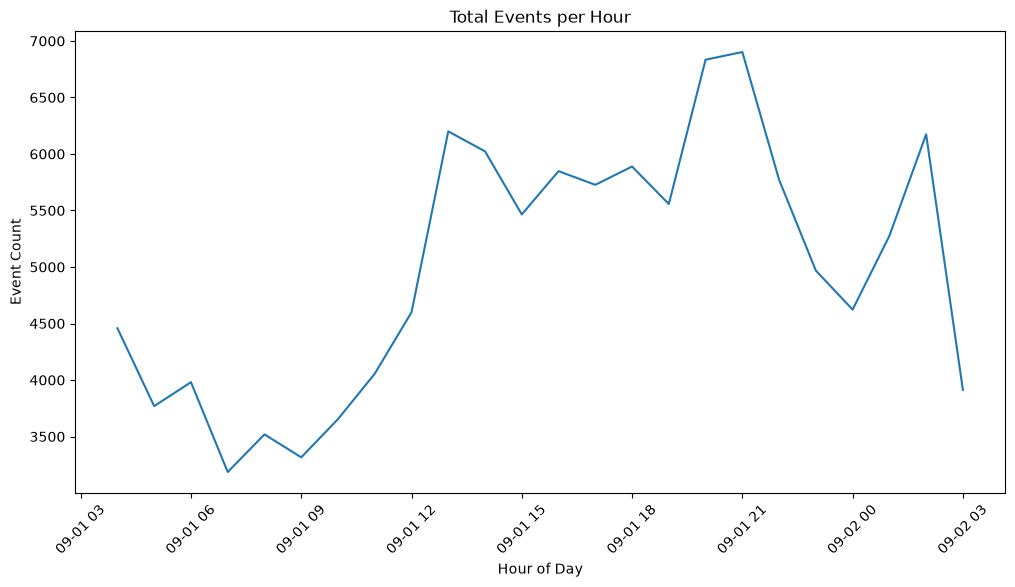

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import os

all_events['datetime'] = pd.to_datetime(all_events['datetime'])
all_events['hour'] = all_events['datetime'].dt.floor('h')

# count events / hour
events_per_hour = all_events.groupby('hour').size().reset_index(name='event_count')

# plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=events_per_hour, x='hour', y='event_count')
plt.title('Total Events per Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Event Count')
plt.xticks(rotation=45)
plt.tight_layout

plt.savefig('images/hourly-events.svg')
plt.savefig('images/hourly-events.png')
plt.show()


## Plot 2

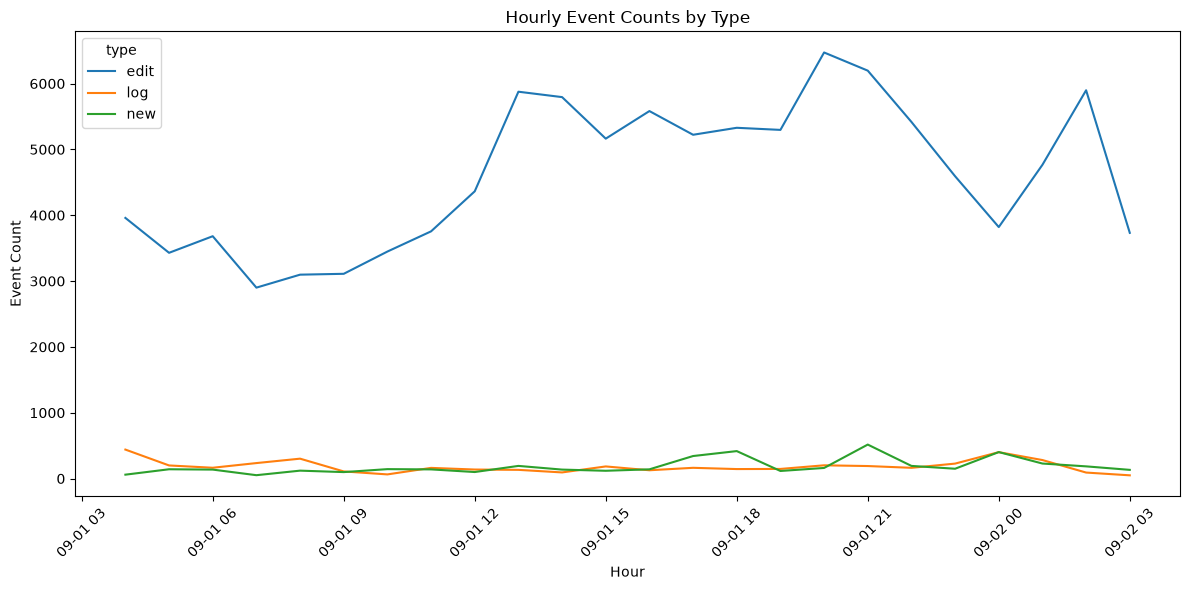

In [5]:
# events / hour, broken down by type
events_by_type = all_events.groupby(['hour', 'type']).size().reset_index(name='event_count')

plt.figure(figsize=(12, 6))
sns.lineplot(data=events_by_type, x='hour', y='event_count', hue='type')
plt.title('Hourly Event Counts by Type')
plt.xlabel('Hour')
plt.ylabel('Event Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('images/events-by-type.svg')
plt.savefig('images/events-by-type.png')
plt.show()